# 04 · Tarea 1 — Capa custom: Ratio de Endeudamiento con saturación

**Objetivo.** Construir una **capa Keras a medida** (`RatioEndeudamientoLayer`, en
`src/custom_layers.py`) colocada **sobre los inputs al principio** del modelo (**D-1.4**) que:

1. Calcula el **ratio de endeudamiento DTI** = `AMT_ANNUITY / (AMT_INCOME_TOTAL + ε)`
   (**D-1.1**, con epsilon en el denominador para evitar divisiones por cero/nulos, **D-1.5**).
2. Aplica una **saturación con exponente entrenable** `x^p`, con `p ∈ [0.1, 3]`, init `1`
   y **clip** sobre el parámetro (**D-1.2** / **D-1.3**). Init a 1 ⇒ la capa arranca como
   identidad; el clip evita inestabilidad numérica.
3. **Concatena** el ratio a las **13 features** sin sustituirlas (**D-1.6**), para no perder
   información que las densas sí usan.

Esta capa se reutilizará en los notebooks **06** (Keras Tuner) y opcionalmente **05** (FAIR loss),
y hereda la arquitectura del **03 base**.

**Entregables de este notebook:** **E1** (código de entrenamiento/evaluación) y **E4** (curva de
loss de convergencia), la **explicación de la restricción matemática** de la capa (para la
presentación), la tabla `results/tables/04_custom__metricas_test.csv` y, opcionalmente, la figura
de exponentes `p` aprendidos.

## Decisiones a tomar antes de empezar

> Fichas de `docs/DECISIONES.md` para esta tarea. **Estado real** copiado tal cual.
> Las decisiones en **Propuesta**/**Abierta** se **validan con el grupo ANTES de
> implementar**: este notebook asume la *Propuesta* por defecto, pero es revisable.

| Decisión | Opciones | Estado |
|---|---|---|
| **D-1.1** · Columnas del ratio de endeudamiento | (a) `AMT_ANNUITY/AMT_INCOME_TOTAL` (DTI) / (b) `AMT_CREDIT/AMT_INCOME_TOTAL` / (c) varios ratios / (d) todas-con-todas (descartada) | Propuesta |
| **D-1.2** · Qué saturación aplicar | (a) exponente entrenable `x^p` / (b) sigmoide / (c) clip directo / (d) normalización acotada | Propuesta |
| **D-1.3** · Rango e inicialización | `p∈[0.1,3]` init 1 (clip sobre el parámetro) / otros rangos | Propuesta |
| **D-1.4** · Posición de la capa | (a) inputs crudos al principio / (b) capa interna / (c) ambas | Propuesta |
| **D-1.5** · Divisiones por cero / nulos | (a) epsilon en denominador / (b) recorte previo / (c) imputar antes | Propuesta |
| **D-1.6** · Salida de la capa | (a) solo ratios / (b) concatenar ratio a las features originales | Propuesta |

Propuestas razonadas en `docs/DECISIONES.md` (**D-1.1–D-1.6**); teoría en
`docs/teoria/01-capa-custom.md`. **Validar con el grupo antes de codificar.**

> ⚠️ **Caveat importante (escala de las features).** Las 13 features ya llegan
> **`log1p` + winsorizadas + escaladas** desde el preprocesado (**D-P.3** / **D-P.5**),
> así que el ratio que la capa calcula se construye sobre **columnas ya transformadas**:
> es un **proxy de DTI en escala transformada**, *no* el cociente euros/euros crudo.
> Es coherente con la teoría (§4: la saturación sobre cantidades ya acotadas aporta poco;
> aquí el ratio es una característica derivada útil, no un DTI literal). **Avisarlo y
> validarlo con el grupo.** Índices útiles dentro de `X` (orden fijado por el contrato):
> **`AMT_INCOME_TOTAL` = col 0** y **`AMT_ANNUITY` = col 2**.

In [1]:
# === Setup comun (notebooks de modelado 03-07) ===
import os
import sys
import json
import random
from pathlib import Path

os.environ["KERAS_BACKEND"] = "tensorflow"   # backend unico para todo el grupo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def _is_project_root(path: Path) -> bool:
    """True si path es la raiz del repo (contiene data/, src/ y notebooks/)."""
    return (
        (path / "data").is_dir()
        and (path / "src").is_dir()
        and (path / "notebooks").is_dir()
    )


def resolve_project_root() -> Path:
    """Detecta la raiz del proyecto desde el cwd o la ubicacion del notebook."""
    anchors: list[Path] = [Path.cwd().resolve()]

    try:
        from IPython import get_ipython
        ip = get_ipython()
        if ip is not None:
            nb_path = ip.user_ns.get("__vsc_ipynb_file__")  # VS Code / Cursor
            if nb_path:
                anchors.append(Path(nb_path).resolve().parent)
            startup_dir = getattr(ip, "startup_dir", None)
            if startup_dir:
                anchors.append(Path(startup_dir).resolve())
    except Exception:
        pass

    seen: set[str] = set()
    for anchor in anchors:
        # Subir desde cwd o desde notebooks/
        for candidate in (anchor, *anchor.parents):
            key = str(candidate)
            if key in seen:
                continue
            seen.add(key)
            if _is_project_root(candidate):
                return candidate

        # Fallback: subcarpeta directa (p. ej. PRACTICA4/TALLER_FAIR_CREDIT_MODEL)
        if anchor.is_dir():
            for child in anchor.iterdir():
                if child.is_dir() and _is_project_root(child):
                    return child.resolve()

    raise FileNotFoundError(
        "No se encontro la raiz del proyecto (carpeta con data/, src/ y notebooks/). "
        f"Directorios de partida: {[str(p) for p in anchors]}"
    )


PROJECT_ROOT = resolve_project_root()
PROC_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "results" / "figures"
TAB_DIR = PROJECT_ROOT / "results" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

# Permite importar src.* desde cualquier cwd
_src_root = str(PROJECT_ROOT)
if _src_root not in sys.path:
    sys.path.insert(0, _src_root)

# Reproducibilidad
RNG = 42
np.random.seed(RNG)
random.seed(RNG)
try:
    import keras
    keras.utils.set_random_seed(RNG)
except Exception:
    pass

# Estilo heredado del EDA / preprocesado
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
COLOR_PAGA   = "#2c7fb8"   # TARGET=0  (paga)
COLOR_IMPAGA = "#d7301f"   # TARGET=1  (impaga)
COLOR_ACENTO = "#41ab5d"   # neutro

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"PROC_DIR    : {PROC_DIR}")

import importlib
import keras

# Recarga src.custom_layers desde disco (util al editar la capa sin reiniciar kernel)
for _mod in ("src.custom_layers", "src"):
    sys.modules.pop(_mod, None)
if _src_root in sys.path:
    sys.path.remove(_src_root)
sys.path.insert(0, _src_root)

import src.custom_layers as _custom_layers_mod
importlib.reload(_custom_layers_mod)

from src.custom_layers import DebtRatioSaturatingLayer, RatioEndeudamientoLayer

assert RatioEndeudamientoLayer is DebtRatioSaturatingLayer
print("DebtRatioSaturatingLayer:", DebtRatioSaturatingLayer)
print("Modulo cargado desde:", Path(_custom_layers_mod.__file__).resolve())

PROJECT_ROOT: C:\Users\gonde\Desktop\PRACTICA4\TALLER_FAIR_CREDIT_MODEL
PROC_DIR    : C:\Users\gonde\Desktop\PRACTICA4\TALLER_FAIR_CREDIT_MODEL\data\processed
DebtRatioSaturatingLayer: <class 'src.custom_layers.DebtRatioSaturatingLayer'>
Modulo cargado desde: C:\Users\gonde\Desktop\PRACTICA4\TALLER_FAIR_CREDIT_MODEL\src\custom_layers.py


In [2]:
# --- Metadatos (fuente de verdad: metadata.json del preprocesado) ---
# PROC_DIR, PROJECT_ROOT, etc. vienen del setup comun (celda anterior).

_meta_path = PROC_DIR / "metadata.json"
if not _meta_path.exists():
    raise FileNotFoundError(
        f"No existe {_meta_path}. Ejecuta primero notebooks/02_preprocesado.ipynb "
        f"para generar data/processed/."
    )

META = json.loads(_meta_path.read_text(encoding="utf-8"))
FEATURES_X = META["columns"]["features_X"]   # 13 features, en orden
SENSIBLE   = META["columns"]["sensible"]     # "CODE_GENDER"  (s)
TARGET     = META["columns"]["target"]       # "TARGET"       (y)


def cargar_split(nombre):
    """Devuelve (X, y, s) para 'train' | 'val' | 'test'.
    X = DataFrame solo con las 13 features (SIN genero).
    y = Series TARGET (1=impaga, 0=paga).  s = Series CODE_GENDER (M=1/F=0).
    """
    df = pd.read_parquet(PROC_DIR / f"{nombre}.parquet")
    X = df[FEATURES_X]          # input del modelo: el genero NUNCA entra aqui
    y = df[TARGET]
    s = df[SENSIBLE]
    assert SENSIBLE not in X.columns, "FUGA: el genero esta dentro de X"
    return X, y, s


# Materializar los tres cortes
X_train, y_train, s_train = cargar_split("train")
X_val,   y_val,   s_val   = cargar_split("val")
X_test,  y_test,  s_test  = cargar_split("test")

# Resumen de control
print(f"{'split':<7}{'X (filas, cols)':>20}{'y':>12}{'s':>12}{'tasa_impago':>14}")
for n, (X, y, s) in {"train": (X_train, y_train, s_train),
                     "val":   (X_val,   y_val,   s_val),
                     "test":  (X_test,  y_test,  s_test)}.items():
    print(f"{n:<7}{str(tuple(X.shape)):>20}{str(tuple(y.shape)):>12}"
          f"{str(tuple(s.shape)):>12}{y.mean():>14.4%}")

# --- Auditoria del pipeline de datos (D-P.*) ---
# Los parquets de 02_preprocesado YA incluyen log1p + winsor + imputacion + StandardScaler.
# NO se vuelve a aplicar preprocessor.joblib aqui (contrato NB 03-07).
_cont = META["columns"].get("features_continuas", FEATURES_X[:8])
print("\n=== Auditoria de escala (train, features continuas) ===")
_desc = X_train[_cont].describe().loc[["mean", "std", "min", "max"]].round(3)
print(_desc.to_string())

# Comprobacion rapida: continuas ~ N(0,1) tras el preprocesado
if _desc.loc["std"].max() > 1.5 or _desc.loc["std"].min() < 0.5:
    print("AVISO: std fuera de [0.5, 1.5] en alguna continua -> revisa 02_preprocesado.")
if _desc.loc["mean"].abs().max() > 0.05:
    print("AVISO: media alejada de 0 en alguna continua -> revisa 02_preprocesado.")

# Nota: NO cargamos preprocessor.joblib en este notebook. joblib necesita las clases
# custom del NB 02 (WinsorizerHigh, Log1pColumns, ...) y falla con AttributeError aqui.
# Fuente de verdad para el modelado: train/val/test.parquet + metadata.json.
print("\nDatos listos: parquets preprocesados (sin re-aplicar preprocessor.joblib).")

split       X (filas, cols)           y           s   tasa_impago
train          (215254, 13)   (215254,)   (215254,)       8.0728%
val             (46126, 13)    (46126,)    (46126,)       8.0735%
test            (46127, 13)    (46127,)    (46127,)       8.0734%

=== Auditoria de escala (train, features continuas) ===
      AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3  DAYS_EMPLOYED  DAYS_BIRTH
mean            -0.000      -0.000        0.000        -0.000        -0.000         0.000          0.000       0.000
std              1.000       1.000        1.000         1.000         1.000         1.000          1.000       1.000
min             -3.606      -3.288       -4.902        -3.516        -2.696        -2.945         -7.329      -1.959
max              3.695       2.994        4.378         3.288         1.783         2.177          1.052       2.108

Datos listos: parquets preprocesados (sin re-aplicar preprocessor.joblib).


## Definición de la capa custom

La capa `RatioEndeudamientoLayer` vive en `src/custom_layers.py` (módulo `custom_layers.py` ↔ NB 04).
Sigue el patrón canónico `__init__` / `build` / `call` y usa **solo `keras.ops`** para ser
agnóstica del backend (teoría §3). Calcula el DTI (**D-1.1**, cols 2/0 con epsilon **D-1.5**),
aplica el exponente entrenable acotado `x^p` (**D-1.2** / **D-1.3**) y concatena el ratio a las
features originales (**D-1.6**). Ver teoría `docs/teoria/01-capa-custom.md` §2–§3.

In [3]:
# Verificacion del contrato D-1.1 a D-1.6 (recargar capa si editaste src/custom_layers.py)
importlib.reload(_custom_layers_mod)
from src.custom_layers import DebtRatioSaturatingLayer, RatioEndeudamientoLayer

_capa = DebtRatioSaturatingLayer(
    income_idx=0, annuity_idx=2, n_features=X_train.shape[1],
    name="capa_dti_saturacion",
)
_probe = X_train.iloc[:512].to_numpy("float32")
_out = _capa(keras.ops.convert_to_tensor(_probe))
_out_np = keras.ops.convert_to_numpy(_out)

print("Forma de salida:", tuple(_out.shape), "-> 13 features + 1 ratio DTI saturado")
print("Exponente p inicial:", float(keras.ops.convert_to_numpy(_capa.p).reshape(-1)[0]))
print("Salida capa  min/max:", float(_out_np.min()), float(_out_np.max()))
print("NaN en salida capa:", bool(np.isnan(_out_np).any()))
if np.isnan(_out_np).any() or np.abs(_out_np).max() > 50:
    raise ValueError("Salida de la capa inestable: revisa DTI_DENOM_EPS / clip en custom_layers.py")

Forma de salida: (512, 14) -> 13 features + 1 ratio DTI saturado
Exponente p inicial: 1.0
Salida capa  min/max: -6.482187271118164 4.674369812011719
NaN en salida capa: False


## Modelo que usa la capa

Se reutiliza la **arquitectura del 03 base** (MLP estándar), insertando la capa custom **al
principio** sobre los inputs crudos (**D-1.4**), antes de las densas.

In [4]:
# === MLP con capa custom al inicio (D-1.4) + arquitectura del 03 base ===
# Input(13) -> DebtRatioSaturatingLayer -> 14 -> Dense(64) -> ... -> Dense(1, sigmoid)

N_FEATURES = X_train.shape[1]   # 13 features (sin genero)
DROPOUT_RATE = 0.3              # FIJO (palanca D-3.2 / D-4.1, heredado del base)

entrada = keras.Input(shape=(N_FEATURES,), name="entrada_13_features")
x = DebtRatioSaturatingLayer(
    income_idx=0,
    annuity_idx=2,
    n_features=N_FEATURES,
    name="capa_dti_saturacion",
)(entrada)

x = keras.layers.Dense(64, activation="relu", name="densa_1")(x)
x = keras.layers.Dropout(DROPOUT_RATE, name="dropout_1")(x)
x = keras.layers.Dense(32, activation="relu", name="densa_2")(x)
x = keras.layers.Dropout(DROPOUT_RATE, name="dropout_2")(x)
salida = keras.layers.Dense(1, activation="sigmoid", name="salida_impago")(x)

model = keras.Model(inputs=entrada, outputs=salida, name="mlp_custom_dti")

model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(),
    metrics=[keras.metrics.AUC(name="auc"), "accuracy"],
)

model.summary()

Model: "mlp_custom_dti"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada_13_features             │ (None, 13)             │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_dti_saturacion             │ (None, 14)             │             1 │
│ (DebtRatioSaturatingLayer)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_1 (Dense)                 │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_impago (Dense)           │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,074 (12.01 KB)

 Trainable params: 3,074 (12.01 KB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento (curva de loss, E4)

Entrenamiento del modelo final con `train` y validación con `val`; la **curva de loss** que
muestra la convergencia es el entregable **E4**.

class_weight (balanced desde train): {0: 0.5439, 1: 6.1936}
Epoch 1/150
421/421 - 1s - 2ms/step - accuracy: 0.6861 - auc: 0.7381 - loss: 0.6031 - val_accuracy: 0.6993 - val_auc: 0.7397 - val_loss: 0.5820
Epoch 2/150
421/421 - 1s - 2ms/step - accuracy: 0.6864 - auc: 0.7379 - loss: 0.6031 - val_accuracy: 0.7016 - val_auc: 0.7394 - val_loss: 0.5878
Epoch 3/150
421/421 - 1s - 2ms/step - accuracy: 0.6895 - auc: 0.7385 - loss: 0.6029 - val_accuracy: 0.7011 - val_auc: 0.7396 - val_loss: 0.5832
Epoch 4/150
421/421 - 1s - 2ms/step - accuracy: 0.6853 - auc: 0.7383 - loss: 0.6029 - val_accuracy: 0.6972 - val_auc: 0.7395 - val_loss: 0.5928
Epoch 5/150
421/421 - 1s - 2ms/step - accuracy: 0.6873 - auc: 0.7385 - loss: 0.6025 - val_accuracy: 0.6994 - val_auc: 0.7398 - val_loss: 0.5907
Epoch 6/150
421/421 - 1s - 2ms/step - accuracy: 0.6867 - auc: 0.7389 - loss: 0.6021 - val_accuracy: 0.6938 - val_auc: 0.7395 - val_loss: 0.5885
Epoch 7/150
421/421 - 1s - 2ms/step - accuracy: 0.6855 - auc: 0.7391 - loss:

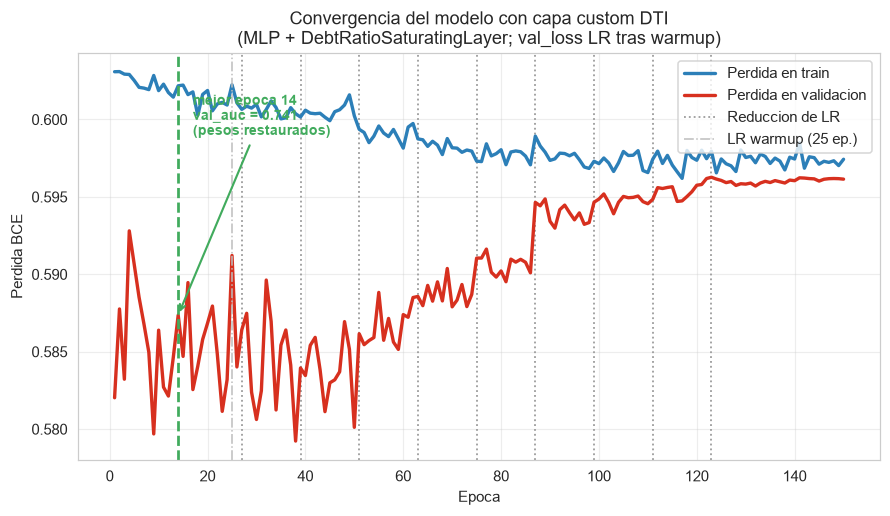

In [6]:
# === Entrenamiento + curva de loss (entregable E4) ===
import tempfile
from sklearn.utils.class_weight import compute_class_weight

cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train.to_numpy())
class_weight = {0: float(cw[0]), 1: float(cw[1])}
print(f"class_weight (balanced desde train): {{0: {class_weight[0]:.4f}, 1: {class_weight[1]:.4f}}}")

Xtr = X_train.to_numpy("float32"); ytr = y_train.to_numpy("float32")
Xvl = X_val.to_numpy("float32");   yvl = y_val.to_numpy("float32")

EPOCHS = 150
LR_WARMUP_EPOCHS = 25          # no reducir LR mientras la red arranca (AUC ~0.5 al inicio es normal)
ckpt_path = os.path.join(tempfile.gettempdir(), "04_custom_best.weights.h5")


class DelayedReduceLROnPlateau(keras.callbacks.Callback):
    """ReduceLROnPlateau que solo actua tras start_epoch (monitor = val_loss)."""

    def __init__(self, start_epoch, **reduce_kwargs):
        super().__init__()
        self.start_epoch = start_epoch
        self.reduce = keras.callbacks.ReduceLROnPlateau(**reduce_kwargs)

    def set_model(self, model):
        super().set_model(model)
        self.reduce.set_model(model)

    def on_train_begin(self, logs=None):
        self.reduce.on_train_begin(logs)

    def on_epoch_end(self, epoch, logs=None):
        if epoch + 1 >= self.start_epoch:
            self.reduce.on_epoch_end(epoch, logs)


reduce_lr = DelayedReduceLROnPlateau(
    start_epoch=LR_WARMUP_EPOCHS,
    monitor="val_loss",
    mode="min",
    factor=0.5,
    patience=12,
    min_lr=1e-6,
    verbose=1,
)
checkpoint = keras.callbacks.ModelCheckpoint(
    ckpt_path,
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    save_weights_only=True,
    verbose=0,
)

history = model.fit(
    Xtr, ytr,
    validation_data=(Xvl, yvl),
    class_weight=class_weight,
    epochs=EPOCHS,
    batch_size=512,
    callbacks=[reduce_lr, checkpoint],
    verbose=2,
)

model.load_weights(ckpt_path)

val_auc_hist = history.history["val_auc"]
n_epocas = len(history.history["loss"])
best_epoch = int(np.argmax(val_auc_hist))
best_val_auc = float(val_auc_hist[best_epoch])
print(f"\nEpocas ejecutadas: {n_epocas}")
print(f"Mejor val_auc: {best_val_auc:.4f} (epoca {best_epoch + 1}) -> pesos restaurados")
print(f"val_loss final: {history.history['val_loss'][-1]:.4f}  (azar ~0.693)")

lr_hist = history.history.get("learning_rate", history.history.get("lr"))
epocas_lr_drop = []
if lr_hist is not None:
    for i in range(1, len(lr_hist)):
        if lr_hist[i] < lr_hist[i - 1] - 1e-12:
            epocas_lr_drop.append(i + 1)

loss_tr  = history.history["loss"]
loss_val = history.history["val_loss"]
epocas   = np.arange(1, n_epocas + 1)

fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.plot(epocas, loss_tr,  color=COLOR_PAGA,   lw=2.2, label="Perdida en train")
ax.plot(epocas, loss_val, color=COLOR_IMPAGA, lw=2.2, label="Perdida en validacion")

y_top = max(max(loss_tr), max(loss_val))
y_bot = min(min(loss_tr), min(loss_val))

for k, e in enumerate(epocas_lr_drop):
    ax.axvline(e, color="#9e9e9e", ls=":", lw=1.2, zorder=1,
               label="Reduccion de LR" if k == 0 else None)

if LR_WARMUP_EPOCHS <= n_epocas:
    ax.axvline(LR_WARMUP_EPOCHS, color="#bdbdbd", ls="-.", lw=1.0,
               label=f"LR warmup ({LR_WARMUP_EPOCHS} ep.)")

ax.axvline(best_epoch + 1, color=COLOR_ACENTO, ls="--", lw=1.8, zorder=2)
ax.annotate(
    f"mejor epoca {best_epoch + 1}\nval_auc = {best_val_auc:.3f}\n(pesos restaurados)",
    xy=(best_epoch + 1, loss_val[best_epoch]),
    xytext=(best_epoch + 1 + 3, y_top - 0.06 * (y_top - y_bot)),
    color=COLOR_ACENTO, fontsize=9, fontweight="bold", ha="left", va="top",
    arrowprops=dict(arrowstyle="->", color=COLOR_ACENTO, lw=1.4),
)

ax.set_title("Convergencia del modelo con capa custom DTI\n"
             "(MLP + DebtRatioSaturatingLayer; val_loss LR tras warmup)",
             fontsize=11.5)
ax.set_xlabel("Epoca")
ax.set_ylabel("Perdida BCE")
ax.legend(loc="upper right", frameon=True)
ax.grid(True, alpha=0.35)
fig.tight_layout()

ruta_e4 = FIG_DIR / "04_custom__curva_loss.png"
fig.savefig(ruta_e4, bbox_inches="tight", dpi=150)
print(f"Figura E4 guardada en: {ruta_e4}")
plt.show()

## Evaluación (AUC / accuracy / group gap)

Métricas en **test** y auditoría de equidad (group gap M−F con `s_test`), comparadas con la
línea base del 03 si está disponible. La línea base de equidad fijada por el EDA es **+3,14 pp**
(**D-2.3**).

=== Precision en test ===
AUC-ROC  : 0.7437
Accuracy : 0.6891 (umbral 0.5)

=== Auditoria de equidad (group gap M-F) ===
Tasa media predicha M: 46.1524%
Tasa media predicha F: 40.8178%
group_gap_pp (M - F) : +5.33 pp

Baseline EDA (impago real): +3.14 pp

Comparacion con modelo base (03):
  AUC base: 0.7437  |  AUC custom: 0.7437  |  delta: -0.0000
  gap base: +5.35 pp  |  gap custom: +5.33 pp
Figura exponentes guardada en: C:\Users\gonde\Desktop\PRACTICA4\TALLER_FAIR_CREDIT_MODEL\results\figures\04_custom__exponentes_p_aprendidos.png


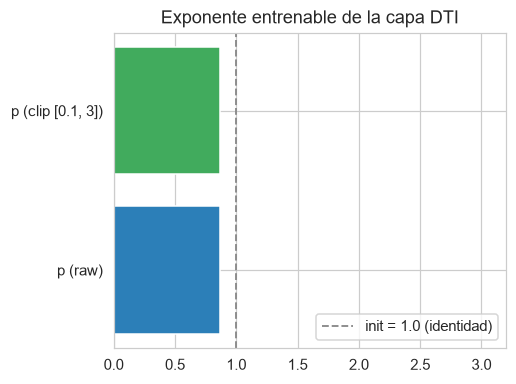

Tabla de metricas guardada en: C:\Users\gonde\Desktop\PRACTICA4\TALLER_FAIR_CREDIT_MODEL\results\tables\04_custom__metricas_test.csv


,modelo,AUC_ROC,accuracy,group_gap_pp,tasa_pred_M,tasa_pred_F,p_aprendido,p_clip
0,custom (capa DTI),0.7437,0.6891,5.3347,0.4615,0.4082,0.8692,0.8692


In [7]:
# === Evaluacion en test: precision (D-2.4) + auditoria de equidad (D-2.3) ===
from sklearn.metrics import roc_auc_score, accuracy_score

proba_test = model.predict(X_test.to_numpy("float32"), verbose=0).ravel()

auc_test = roc_auc_score(y_test, proba_test)
pred_test = (proba_test >= 0.5).astype(int)
acc_test = accuracy_score(y_test, pred_test)

s_vals = s_test.values
tasa_pred_M = proba_test[s_vals == 1].mean()
tasa_pred_F = proba_test[s_vals == 0].mean()
group_gap_pp = (tasa_pred_M - tasa_pred_F) * 100.0

print("=== Precision en test ===")
print(f"AUC-ROC  : {auc_test:.4f}")
print(f"Accuracy : {acc_test:.4f} (umbral 0.5)")
print("\n=== Auditoria de equidad (group gap M-F) ===")
print(f"Tasa media predicha M: {tasa_pred_M:.4%}")
print(f"Tasa media predicha F: {tasa_pred_F:.4%}")
print(f"group_gap_pp (M - F) : {group_gap_pp:+.2f} pp")

baseline_eda_pp = 3.14
print(f"\nBaseline EDA (impago real): {baseline_eda_pp:+.2f} pp")

ruta_base = TAB_DIR / "03_base__metricas_test.csv"
if ruta_base.exists():
    base_metrics = pd.read_csv(ruta_base)
    auc_base = float(base_metrics.loc[0, "AUC_ROC"])
    gap_base = float(base_metrics.loc[0, "group_gap_pp"])
    print(f"\nComparacion con modelo base (03):")
    print(f"  AUC base: {auc_base:.4f}  |  AUC custom: {auc_test:.4f}  |  delta: {auc_test - auc_base:+.4f}")
    print(f"  gap base: {gap_base:+.2f} pp  |  gap custom: {group_gap_pp:+.2f} pp")
else:
    print("\nNota: no existe results/tables/03_base__metricas_test.csv; ejecuta el notebook 03 para comparar.")

# Exponente p aprendido (opcional)
capa_custom = model.get_layer("capa_dti_saturacion")
p_raw = float(keras.ops.convert_to_numpy(capa_custom.p).reshape(-1)[0])
p_clip = float(np.clip(p_raw, 0.1, 3.0))

fig, ax = plt.subplots(figsize=(4.8, 3.6))
ax.barh(["p (raw)", "p (clip [0.1, 3])"], [p_raw, p_clip], color=[COLOR_PAGA, COLOR_ACENTO])
ax.axvline(1.0, color="#888888", ls="--", lw=1.2, label="init = 1.0 (identidad)")
ax.set_xlim(0.0, 3.2)
ax.set_title("Exponente entrenable de la capa DTI")
ax.legend(loc="lower right")
fig.tight_layout()
ruta_p = FIG_DIR / "04_custom__exponentes_p_aprendidos.png"
fig.savefig(ruta_p, bbox_inches="tight", dpi=150)
print(f"Figura exponentes guardada en: {ruta_p}")
plt.show()

fila_custom = pd.DataFrame(
    [{
        "modelo": "custom (capa DTI)",
        "AUC_ROC": round(float(auc_test), 4),
        "accuracy": round(float(acc_test), 4),
        "group_gap_pp": round(float(group_gap_pp), 4),
        "tasa_pred_M": round(float(tasa_pred_M), 4),
        "tasa_pred_F": round(float(tasa_pred_F), 4),
        "p_aprendido": round(p_raw, 4),
        "p_clip": round(p_clip, 4),
    }],
    columns=["modelo", "AUC_ROC", "accuracy", "group_gap_pp", "tasa_pred_M", "tasa_pred_F",
             "p_aprendido", "p_clip"],
)

ruta_tabla = TAB_DIR / "04_custom__metricas_test.csv"
fila_custom.to_csv(ruta_tabla, index=False)
print(f"Tabla de metricas guardada en: {ruta_tabla}")
fila_custom

## Entregables

Este notebook produce:

- **E1** · Código de entrenamiento, optimización y evaluación del modelo con capa custom.
- **E4** · Curva de loss del entrenamiento final → `results/figures/04_custom__curva_loss.png`.
- **Tabla** de métricas en test → `results/tables/04_custom__metricas_test.csv`.
- **(Presentación)** Explicación de la **restricción matemática** de la capa
  (DTI + exponente entrenable acotado `p∈[0.1,3]` con clip, **D-1.1–D-1.6**).
- *(Opcional)* Figura de exponentes `p` aprendidos → `results/figures/04_custom__exponentes_p_aprendidos.png`.

**Dependencias.** Usa la **arquitectura del 03 base**; la `RatioEndeudamientoLayer` que aquí se
define la **reutilizan el 06 (Keras Tuner)** y **opcionalmente el 05 (FAIR loss)**. Mapa completo
en `docs/CONVENCIONES_MODELADO.md` (e).